In [1]:
import os
import re
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
#Set data directory
os.chdir ("/home/kdetest/Documents/VICCO/Palynology/")

In [2]:
pattern = r"(\d+_\d+-\d+)(?:_\w)?"
stem = "35_10-8_S"
m = re.match(pattern, stem)
print(m.group(0))  # Output: 35_10-8_S

stem = "35_10-8"
m = re.match(pattern, stem)
print(m.group(0))  # Output: 35_10-8

35_10-8_S
35_10-8


In [3]:
# Folder with CSVs
palyno_folder = "DISKOS_PalyRAW2_CSV"

APECTODINIUM_SPECIES = [
    "Apectodinium_augustum_cnt",
    "Apectodinium_cornufruticosum_cnt",
    "Apectodinium_folliculum_cnt",
    "Apectodinium_homomorphum_cnt",
    "Apectodinium_hyperacanthum_cnt",
    "Apectodinium_paniculatum_cnt",
    "Apectodinium_parvum_cnt",
    "Apectodinium_quinquelatum_cnt",
    "Apectodinium_summissum_cnt",
    "Apectodinium_tesselatum_cnt",
    "Apectodinium_undiff_cnt",
]

# # Map species names to expected column names
# def species_to_col(name: str) -> str:
#     # Example: "Apectodinium augustum" -> "Apectodinium_augustum_cnt"
#     return name.replace(" ", "_") + "_cnt"

expected_cols = APECTODINIUM_SPECIES

# Loop through all CSVs in the folder
for fpath in glob.glob(os.path.join(palyno_folder, "*.csv")):
    print(f"Processing: {os.path.basename(fpath)}")

    df = pd.read_csv(fpath)

    # Which of the expected Apectodinium columns are actually present?
    apect_cols_present = [c for c in expected_cols if c in df.columns]

    if not apect_cols_present:
        print("  No Apectodinium columns found, skipping.")
        continue

    # Ensure they are numeric
    df[apect_cols_present] = df[apect_cols_present].apply(
        pd.to_numeric, errors="coerce"
    )

    # Create the sum column (row-wise)
    # df["Apectodinium_sum"] = df[apect_cols_present].sum(axis=1)
    # Create the sum column (row-wise), but keep NaN if all inputs are NaN
    df["Apectodinium_sum"] = df[apect_cols_present].sum(axis=1, min_count=1)



    # Save back (overwrite) or to a new file
    df.to_csv(fpath, index=False)
    print(f"  Added Apectodinium_sum using: {apect_cols_present}")

Processing: 15_12-11_S_BIOSTRAT_RAW_2.csv
  Added Apectodinium_sum using: ['Apectodinium_augustum_cnt', 'Apectodinium_homomorphum_cnt', 'Apectodinium_hyperacanthum_cnt', 'Apectodinium_quinquelatum_cnt']
Processing: 15_3-1_S_BIOSTRAT_RAW_2.csv
  Added Apectodinium_sum using: ['Apectodinium_augustum_cnt', 'Apectodinium_homomorphum_cnt', 'Apectodinium_paniculatum_cnt', 'Apectodinium_parvum_cnt', 'Apectodinium_quinquelatum_cnt', 'Apectodinium_summissum_cnt', 'Apectodinium_undiff_cnt']
Processing: 15_3-5_BIOSTRAT_RAW_2.csv
  Added Apectodinium_sum using: ['Apectodinium_augustum_cnt', 'Apectodinium_undiff_cnt']
Processing: 15_9-19_A_BIOSTRAT_RAW_2.csv
  No Apectodinium columns found, skipping.
Processing: 17_4-1_BIOSTRAT_RAW_2.csv
  Added Apectodinium_sum using: ['Apectodinium_augustum_cnt', 'Apectodinium_homomorphum_cnt', 'Apectodinium_undiff_cnt']
Processing: 25_1-5_BIOSTRAT_RAW_2.csv
  Added Apectodinium_sum using: ['Apectodinium_homomorphum_cnt', 'Apectodinium_quinquelatum_cnt', 'Apectod

In [ ]:
# # ------------ USER SETTINGS ------------
# # palyno_folder = "PalyCSV_IndvSpCnt/Apectodinium_Augustum"    # folder with palynology CSVs
# palyno_folder = "DISKOS_PalyRAW2_CSV"    # folder with palynology CSVs


# # Can use single species column
# # Or can use a dictionary of species
# species_cols = [
#     "Apectodinium_augustum_cnt",
#     "Apectodinium_augustum_abn",
#     # "Apectodinium_parvum_cnt",
#     # "Apectodinium_sum",
#     "Cerodinium_wardenense_cnt",
#     "Deflandrea_oebisfeldensis_cnt",
#     "Azolla_cnt",
#     "Azolla_abn"
#     "Azolla_p_out"
#     # "spiniferites_ramosus_cnt"
# ]

# species_colors = {
#     "Apectodinium_augustum_cnt": "darkviolet",
#     "Apectodinium_augustum_abn": "violet",
#     # "Apectodinium_parvum_cnt": "dodgerblue",
#     # "Apectodinium_sum": "#AB8732",
#     "Cerodinium_wardenense_cnt": "indianred",
#     "Deflandrea_oebisfeldensis_cnt": "darkorange",
#     "Azolla_cnt": "springgreen",
#     "Azolla_abn": "yellowgreen",
#     "Azolla_p_out": "forestgreen",
#     # "spiniferites_ramosus_cnt": "crimson"
# }


# depth_col     = "depth"
# # units_file    = "Fm_Tops.xlsx"  # the extra file you showed
# units_file    = "strat_litho_wellbore.xlsx"
# wlb_col       = "Wellbore name"
# top_col       = "Top depth [m]"
# bot_col       = "Bottom depth [m]"
# lsu_name_col  = "Lithostrat. unit"

# formations_to_show = ["BALDER FM", "INTRA BALDER FM SS", "HERMOD FM",  "SELE FM", "FRIGG FM", "FISKEBANK FM", "FORTIES FM", "LISTA FM", "HEIMDAL FM", "TANG FM", "TARE FM", "TORSK FM", ]
# formation_colors = {"BALDER FM": "#6D9457", "INTRA BALDER FM SS": "#F8F362", "HERMOD FM": "#C9C208", "SELE FM": "#1A1A1A", "FRIGG FM": "#F9BA34", "FISKEBANK FM": "#DE9A07", "FORTIES FM": "#724F04", "LISTA FM": "#C7AFAF","HEIMDAL FM": "#7B5656", "TANG FM": "#8DE2FB", "TARE FM": "#057B9E", "TORSK FM": "#086CF7",}
# # ---------------------------------------


# def palyno_well_key_from_fname(fname: str) -> str:
#     stem = os.path.splitext(fname)[0]
#     # m = re.match(r"(\d+_\d+-\d+)(?:_\w)?", stem)
#     m = re.match(r"(\d+_\d+-\d+(?:_\w)?)_", stem)
#     if m:
#         return m.group(1)
#     return stem

# # for df in ?
# #     if name_abn in cols
# #         P=1
# #         R=2
# #         C=5
# #         A=15
# #         D=50

# # --- Load and prepare units file ---
# units = pd.read_excel(units_file)  # change sep="," if needed

# # Optional: keep only formations of interest
# units = units[units[lsu_name_col].isin(formations_to_show)].copy()

# # Normalise names: "17/4-1" -> "17_4-1"
# units["well_key"] = (
#     units[wlb_col]
#     .astype(str)
#     .str.strip()
#     .str.replace("/", "_", regex=False)
#     .str.replace(" ", "_", regex=False)
#     )

# # Ensure depths are numeric
# units[top_col] = pd.to_numeric(units[top_col], errors="coerce")
# units[bot_col] = pd.to_numeric(units[bot_col], errors="coerce")

# # print("Units: unique well_keys:")
# # print(units["well_key"].unique()[:20])   # first few for inspection

# # --- Load palynology data ---
# csv_files = glob.glob(os.path.join(palyno_folder, "*.csv"))

# data_per_file = []
# files_without_species = []

# for fpath in csv_files:
#     fname = os.path.basename(fpath)
#     well_key = palyno_well_key_from_fname(fname)

#     try:
#         df = pd.read_csv(fpath)
#     except Exception as e:
#         print(f"Could not read {fname}: {e}")
#         continue

#     # Check depth + at least one species column exists
#     if depth_col not in df.columns:
#         files_without_species.append(fname)
#         continue

#     present_species = [c for c in species_cols if c in df.columns]
#     if not present_species:
#         files_without_species.append(fname)
#         continue

#     df[depth_col] = pd.to_numeric(df[depth_col], errors="coerce")
#     df = df.dropna(subset=[depth_col])

#     if df.empty:
#         files_without_species.append(fname)
#         continue

#     df = df.sort_values(depth_col)

#     data_per_file.append(
#         {"fname": fname, "well_key": well_key, "df": df, "species_present": present_species}
#     )


# # print("\nPalyno files & inferred well_keys:")
# for item in data_per_file[:10]:
#     print(f"  {item['fname']} -> {item['well_key']}")

# # --- Plot ---
# n = len(data_per_file)
# if n == 0:
#     print("No files with data for these species.")
# else:
#     ncols = math.ceil(math.sqrt(n))
#     nrows = math.ceil(n / ncols)

#     fig, axes = plt.subplots(
#         nrows, ncols,
#         figsize=(6 * ncols, 10 * nrows),
#         sharey=False
#     )
#     axes = axes.flatten() if n > 1 else [axes]

#     species_handles = {}    # label -> Line2D
#     formation_handles = {}  # label -> Patch

#     for ax, item in zip(axes, data_per_file):
#         fname    = item["fname"]
#         well_key = item["well_key"]
#         df       = item["df"]
#         present_species = item["species_present"]

#         # plot each species for this well
#         for sp_col in present_species:
#             color = species_colors.get(sp_col, "grey")
#             df_sp = df.dropna(subset=[sp_col])
#             if df_sp.empty:
#                 continue

#             line = ax.plot(
#                 df_sp[sp_col],
#                 df_sp[depth_col],
#                 marker="o",
#                 markersize='10',
#                 linestyle="-",
#                 linewidth='1',
#                 color=color,
#                 label=sp_col,
#             )[0]  # get the Line2D

#             # keep ONE handle per species
#             if sp_col not in species_handles:
#                 species_handles[sp_col] = line

#         # plot species abundance vlaues on second axis
#         for abn_col in present_species:
#             color = aund_colors.get(abn_col, "grey")
#             df_abn = df.dropna(subset=[abn_col])
#             if df_abn.empty:
#                 continue

#             line = ax.plot(
#                 df_abn[abn_col],
#                 df_abn[depth_col],
#                 marker="o",
#                 markersize='10',
#                 linestyle="-",
#                 linewidth='1',
#                 color=color,
#                 label=abn_col,
#             )[0]  # get the Line2D

#             # keep ONE handle per species
#             if abn_col not in abund_handles:
#                 abund_handles[sp_col] = line

#         ax.invert_yaxis()
#         ax.set_title(fname, fontsize=20)
#         ax.set_xlabel("Count", fontsize=0)
#         ax.set_ylabel(depth_col, fontsize=0)
#         ax.tick_params(axis="both", which="major", labelsize=17)

#         # units for this well
#         this_units = units[units["well_key"] == well_key]
#         for _, row in this_units.iterrows():
#             form_name = row[lsu_name_col]
#             top = row[top_col]
#             bot = row[bot_col]
#             if pd.isna(top) or pd.isna(bot):
#                 continue
#             color = formation_colors.get(form_name, "lightgrey")

#             patch = ax.axhspan(
#                 top,
#                 bot,
#                 color=color,
#                 alpha=0.25,
#                 zorder=0,
#                 label=form_name
#             )

#             # keep ONE handle per formation
#             if form_name not in formation_handles:
#                 formation_handles[form_name] = patch

#     # hide unused axes
#     for ax in axes[n:]:
#         ax.set_visible(False)

#     # single figure-level legend (species + formations), no duplicates
#     all_handles = list(species_handles.values()) + list(formation_handles.values())
#     all_labels  = list(species_handles.keys())   + list(formation_handles.keys())

#     if all_handles:
#         fig.legend(
#             handles=all_handles,
#             labels=all_labels,
#             # loc="upper right",
#             bbox_to_anchor=(0.9, 0.0),
#             fontsize=28,
#             ncols=6
#         )

#     plt.tight_layout()
#     plt.show()

# # fig.savefig("/home/kdetest/Documents/VICCO/Inkscape/Palynology/PalyFm_ApecAug.svg", dpi=400)
# fig.savefig("/home/kdetest/Documents/VICCO/Inkscape/Palynology/PalyFm_KeySpp.svg", dpi=400)
# # print("\nFiles WITHOUT any of the requested species:")
# # for f in files_without_species:
# #     print("  ", f)

  15_12-11_S_BIOSTRAT_RAW_2.csv -> 15_12-11_S
  15_3-1_S_BIOSTRAT_RAW_2.csv -> 15_3-1_S
  15_3-5_BIOSTRAT_RAW_2.csv -> 15_3-5
  17_4-1_BIOSTRAT_RAW_2.csv -> 17_4-1
  25_1-5_BIOSTRAT_RAW_2.csv -> 25_1-5
  25_11-22_BIOSTRAT_RAW_2.csv -> 25_11-22
  25_2-3_BIOSTRAT_RAW_2.csv -> 25_2-3
  25_2-5_BIOSTRAT_RAW_2.csv -> 25_2-5
  25_2-7_BIOSTRAT_RAW_2.csv -> 25_2-7
  25_5-3_BIOSTRAT_RAW_2.csv -> 25_5-3


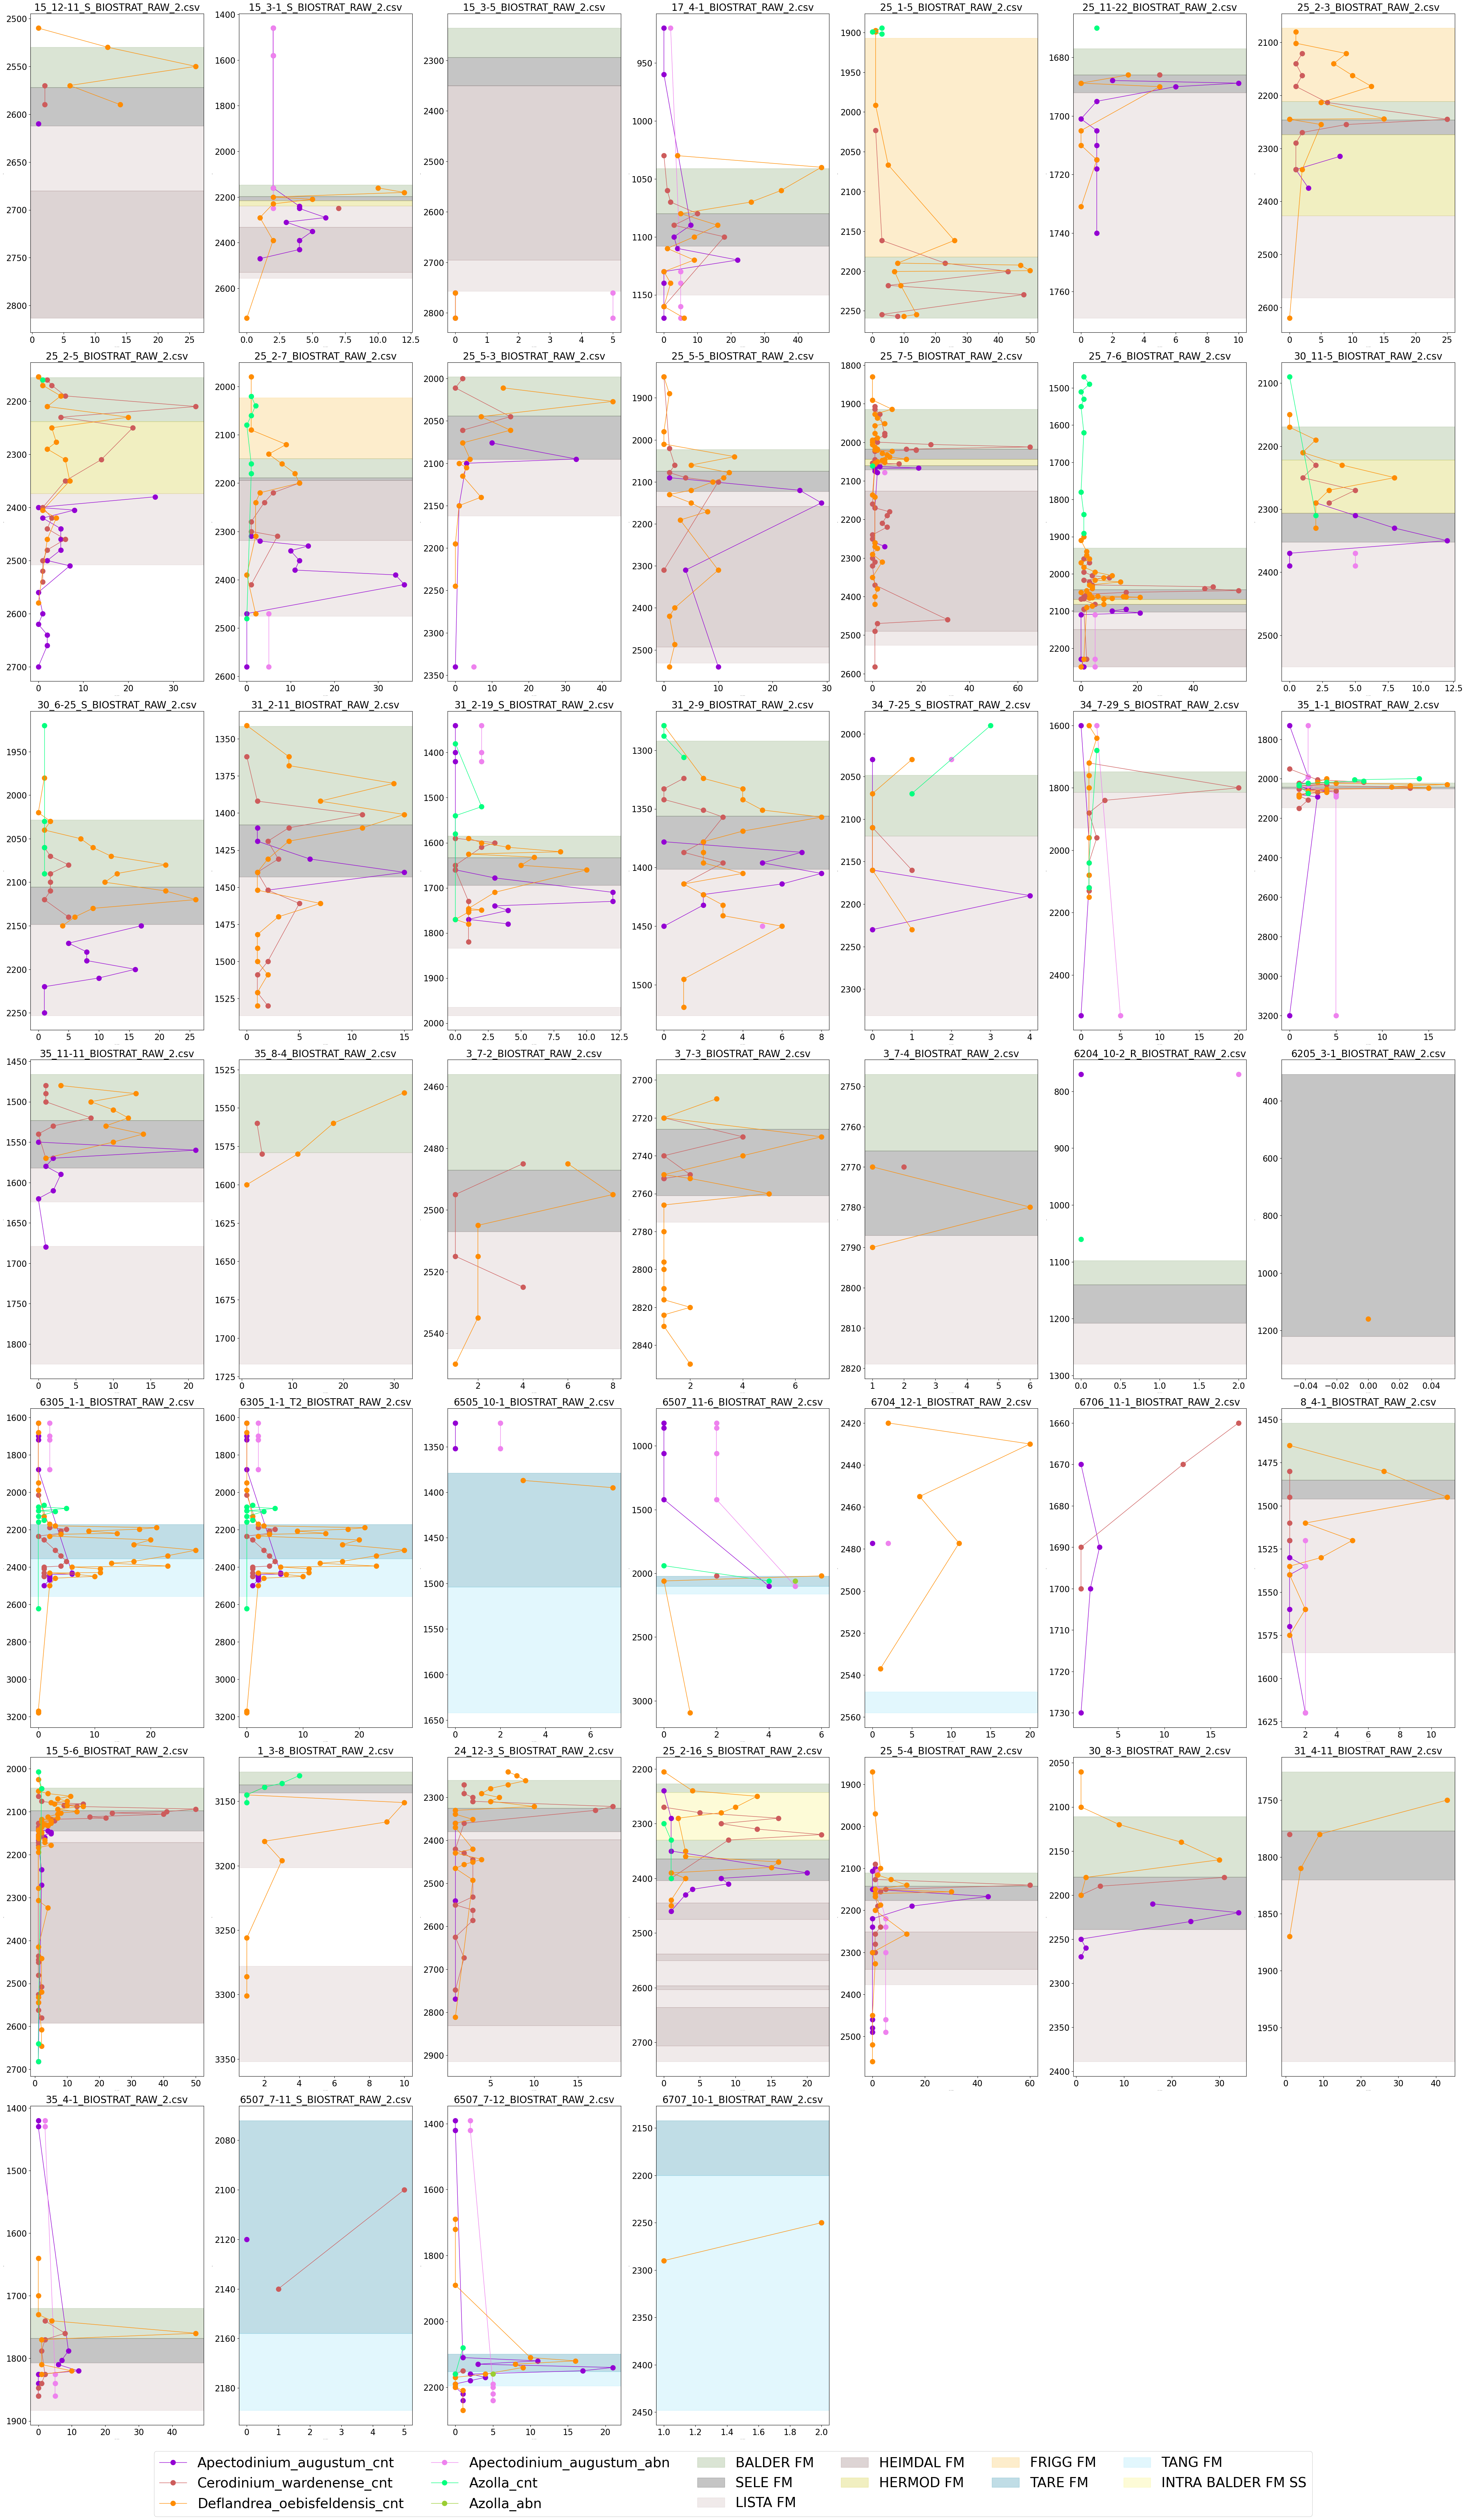

In [11]:
# ------------ USER SETTINGS ------------
palyno_folder = "DISKOS_PalyRAW2_CSV"

species_cols = [
    "Apectodinium_augustum_cnt",
    "Apectodinium_augustum_abn",
    # "Apectodinium_parvum_cnt",
    # "Apectodinium_sum",
    "Cerodinium_wardenense_cnt",
    "Deflandrea_oebisfeldensis_cnt",
    "Azolla_cnt",
    "Azolla_abn",       # ← comma added (was silently concatenated with next line)
    "Azolla_p_out",     # ← now a separate entry
    # "spiniferites_ramosus_cnt"
]

species_colors = {
    "Apectodinium_augustum_cnt": "darkviolet",
    "Apectodinium_augustum_abn": "violet",
    # "Apectodinium_parvum_cnt": "dodgerblue",
    # "Apectodinium_sum": "#AB8732",
    "Cerodinium_wardenense_cnt": "indianred",
    "Deflandrea_oebisfeldensis_cnt": "darkorange",
    "Azolla_cnt": "springgreen",
    "Azolla_abn": "yellowgreen",
    "Azolla_p_out": "forestgreen",
    # "spiniferites_ramosus_cnt": "crimson"
}

depth_col    = "depth"
units_file   = "strat_litho_wellbore.xlsx"
wlb_col      = "Wellbore name"
top_col      = "Top depth [m]"
bot_col      = "Bottom depth [m]"
lsu_name_col = "Lithostrat. unit"

formations_to_show = [
    "BALDER FM", "INTRA BALDER FM SS", "HERMOD FM", "SELE FM", "FRIGG FM",
    "FISKEBANK FM", "FORTIES FM", "LISTA FM", "HEIMDAL FM", "TANG FM", "TARE FM", "TORSK FM",
]
formation_colors = {
    "BALDER FM": "#6D9457", "INTRA BALDER FM SS": "#F8F362", "HERMOD FM": "#C9C208",
    "SELE FM": "#1A1A1A", "FRIGG FM": "#F9BA34", "FISKEBANK FM": "#DE9A07",
    "FORTIES FM": "#724F04", "LISTA FM": "#C7AFAF", "HEIMDAL FM": "#7B5656",
    "TANG FM": "#8DE2FB", "TARE FM": "#057B9E", "TORSK FM": "#086CF7",
}
# ---------------------------------------

# Qualitative abundance → numeric mapping
ABUND_MAP = {"P": 1, "R": 2, "C": 5, "A": 15, "D": 50}


def palyno_well_key_from_fname(fname: str) -> str:
    stem = os.path.splitext(fname)[0]
    m = re.match(r"(\d+_\d+-\d+(?:_\w)?)_", stem)
    if m:
        return m.group(1)
    return stem


# --- Load and prepare units file ---
units = pd.read_excel(units_file)

units = units[units[lsu_name_col].isin(formations_to_show)].copy()

units["well_key"] = (
    units[wlb_col]
    .astype(str)
    .str.strip()
    .str.replace("/", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

units[top_col] = pd.to_numeric(units[top_col], errors="coerce")
units[bot_col] = pd.to_numeric(units[bot_col], errors="coerce")


# --- Load palynology data ---
csv_files = glob.glob(os.path.join(palyno_folder, "*.csv"))

data_per_file = []
files_without_species = []

for fpath in csv_files:
    fname    = os.path.basename(fpath)
    well_key = palyno_well_key_from_fname(fname)

    try:
        df = pd.read_csv(fpath)
    except Exception as e:
        print(f"Could not read {fname}: {e}")
        continue

    # Convert qualitative abundance/presence cols to numeric
    abn_cols = [c for c in df.columns if c.endswith("_abn") or c.endswith("_p_out")]
    for col in abn_cols:
        df[col] = df[col].replace(ABUND_MAP)               # "P"→1, "R"→2 … numbers untouched
        df[col] = pd.to_numeric(df[col], errors="coerce")  # anything else → NaN

    if depth_col not in df.columns:
        files_without_species.append(fname)
        continue

    present_species = [c for c in species_cols if c in df.columns]
    if not present_species:
        files_without_species.append(fname)
        continue

    df[depth_col] = pd.to_numeric(df[depth_col], errors="coerce")
    df = df.dropna(subset=[depth_col])

    if df.empty:
        files_without_species.append(fname)
        continue

    df = df.sort_values(depth_col)

    data_per_file.append(
        {"fname": fname, "well_key": well_key, "df": df, "species_present": present_species}
    )


for item in data_per_file[:10]:
    print(f"  {item['fname']} -> {item['well_key']}")


# --- Plot ---
n = len(data_per_file)
if n == 0:
    print("No files with data for these species.")
else:
    ncols = math.ceil(math.sqrt(n))
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(6 * ncols, 10 * nrows),
        sharey=False
    )
    axes = axes.flatten() if n > 1 else [axes]

    species_handles   = {}  # label -> Line2D
    formation_handles = {}  # label -> Patch

    for ax, item in zip(axes, data_per_file):
        fname           = item["fname"]
        well_key        = item["well_key"]
        df              = item["df"]
        present_species = item["species_present"]

        # Plot all species (_cnt, _abn, _p_out) on the same axis
        for sp_col in present_species:
            color = species_colors.get(sp_col, "grey")
            df_sp = df.dropna(subset=[sp_col])
            if df_sp.empty:
                continue

            line = ax.plot(
                df_sp[sp_col],
                df_sp[depth_col],
                marker="o",
                markersize=10,   # ← was string '10'
                linestyle="-",
                linewidth=1,     # ← was string '1'
                color=color,
                label=sp_col,
            )[0]

            if sp_col not in species_handles:
                species_handles[sp_col] = line

        ax.invert_yaxis()
        ax.set_title(fname, fontsize=20)
        ax.set_xlabel("Count / Abundance", fontsize=0)
        ax.set_ylabel(depth_col, fontsize=0)
        ax.tick_params(axis="both", which="major", labelsize=17)

        # Formation spans for this well
        this_units = units[units["well_key"] == well_key]
        for _, row in this_units.iterrows():
            form_name = row[lsu_name_col]
            top       = row[top_col]
            bot       = row[bot_col]
            if pd.isna(top) or pd.isna(bot):
                continue
            color = formation_colors.get(form_name, "lightgrey")

            patch = ax.axhspan(
                top, bot,
                color=color,
                alpha=0.25,
                zorder=0,
                label=form_name
            )

            if form_name not in formation_handles:
                formation_handles[form_name] = patch

    # Hide unused axes
    for ax in axes[n:]:
        ax.set_visible(False)

    # Single figure-level legend (species + formations), no duplicates
    all_handles = list(species_handles.values()) + list(formation_handles.values())
    all_labels  = list(species_handles.keys())   + list(formation_handles.keys())

    if all_handles:
        fig.legend(
            handles=all_handles,
            labels=all_labels,
            bbox_to_anchor=(0.9, 0.0),
            fontsize=28,
            ncols=6
        )

    plt.tight_layout()
    plt.show()

fig.savefig("/home/kdetest/Documents/VICCO/Inkscape/Palynology/PalyFm_KeySpp.svg", dpi=400)

# print("\nFiles WITHOUT any of the requested species:")
# for f in files_without_species:
#     print("  ", f)

Plotting code below not really working yet - not sure what is being plotted and colours are all the same

In [ ]:
"""
Code using regex to match multiple species of a given genus
"""
# ------------ USER SETTINGS ------------
palyno_folder = "DISKOS_PalyRAW2_CSV"    # folder with palynology CSVs

# Matching multiple columns with regex
species_patterns = [
    r"Apectodinium_augustum_cnt",  # exact
    r"Apectodinium_.*_cnt",        # any Apectodinium_*_cnt
]

species_pattern_colors = {
    r"Apectodinium_augustum_cnt": "black",
    r"Apectodinium_.*_cnt": "black",
}

depth_col     = "depth"
units_file    = "strat_litho_wellbore.xlsx"
wlb_col       = "Wellbore name"
top_col       = "Top depth [m]"
bot_col       = "Bottom depth [m]"
lsu_name_col  = "Lithostrat. unit"

formations_to_show = [
    "BALDER FM", "INTRA BALDER FM SS", "HERMOD FM", "SELE FM", "FRIGG FM",
    "FISKEBANK FM", "FORTIES FM", "LISTA FM", "TANG FM", "TARE FM", "TORSK FM",
]
formation_colors = {
    "BALDER FM": "#6D9457", "INTRA BALDER FM SS": "#F8F362",
    "HERMOD FM": "#C9C208", "SELE FM": "#1A1A1A", "FRIGG FM": "#F9BA34",
    "FISKEBANK FM": "#DE9A07", "FORTIES FM": "#724F04", "LISTA FM": "#C7AFAF",
    "TANG FM": "#8DE2FB", "TARE FM": "#057B9E", "TORSK FM": "#086CF7",
}
# ---------------------------------------


def palyno_well_key_from_fname(fname: str) -> str:
    stem = os.path.splitext(fname)[0]
    m = re.match(r"(\d+_\d+-\d+(?:_\w)?)_", stem)
    if m:
        return m.group(1)
    return stem


# --- Load and prepare units file ---
units = pd.read_excel(units_file)

# Optional: keep only formations of interest
units = units[units[lsu_name_col].isin(formations_to_show)].copy()

# Normalise names: "17/4-1" -> "17_4-1"
units["well_key"] = (
    units[wlb_col]
    .astype(str)
    .str.strip()
    .str.replace("/", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

# Ensure depths are numeric
units[top_col] = pd.to_numeric(units[top_col], errors="coerce")
units[bot_col] = pd.to_numeric(units[bot_col], errors="coerce")

# --- Load palynology data ---
csv_files = glob.glob(os.path.join(palyno_folder, "*.csv"))

data_per_file = []
files_without_species = []

for fpath in csv_files:
    fname = os.path.basename(fpath)
    well_key = palyno_well_key_from_fname(fname)

    try:
        df = pd.read_csv(fpath)
    except Exception as e:
        print(f"Could not read {fname}: {e}")
        continue

    # Check depth exists
    if depth_col not in df.columns:
        files_without_species.append(fname)
        continue

    # find species columns by regex
    present_species = []
    species_colors_per_file = {}

    for pattern in species_patterns:
        matched_cols = [c for c in df.columns if re.fullmatch(pattern, c)]
        if matched_cols:
            color = species_pattern_colors.get(pattern, "grey")
            for col in matched_cols:
                present_species.append(col)
                species_colors_per_file[col] = color

    present_species = list(dict.fromkeys(present_species))  # dedupe

    if not present_species:
        files_without_species.append(fname)
        continue

    # clean depth and sort
    df[depth_col] = pd.to_numeric(df[depth_col], errors="coerce")
    df = df.dropna(subset=[depth_col])

    if df.empty:
        files_without_species.append(fname)
        continue

    df = df.sort_values(depth_col)

    # store for plotting
    data_per_file.append(
        {
            "fname": fname,
            "well_key": well_key,
            "df": df,
            "species_present": present_species,
            "species_colors": species_colors_per_file,
        }
    )

# print("\nPalyno files & inferred well_keys:")
for item in data_per_file[:10]:
    print(f"  {item['fname']} -> {item['well_key']}")

# --- Plot ---
n = len(data_per_file)
if n == 0:
    print("No files with data for these species.")
else:
    ncols = math.ceil(math.sqrt(n))
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(6 * ncols, 10 * nrows),
        sharey=False
    )
    axes = axes.flatten() if n > 1 else [axes]

    species_handles = {}    # label -> Line2D
    formation_handles = {}  # label -> Patch

    for ax, item in zip(axes, data_per_file):
        fname    = item["fname"]
        well_key = item["well_key"]
        df       = item["df"]
        present_species = item["species_present"]
        species_colors_per_file = item["species_colors"]

        # plot each species for this well
        for sp_col in present_species:
            color = species_colors_per_file.get(sp_col, "grey")
            df_sp = df.dropna(subset=[sp_col])
            if df_sp.empty:
                continue

            line = ax.plot(
                df_sp[sp_col],
                df_sp[depth_col],
                marker="o",
                markersize=10,
                linestyle="-",
                linewidth=1,
                color=color,
                label=sp_col,
            )[0]

            if sp_col not in species_handles:
                species_handles[sp_col] = line

        ax.invert_yaxis()
        ax.set_title(fname, fontsize=20)
        ax.set_xlabel("Count", fontsize=0)
        ax.set_ylabel(depth_col, fontsize=0)
        ax.tick_params(axis="both", which="major", labelsize=17)

        # units for this well
        this_units = units[units["well_key"] == well_key]
        for _, row in this_units.iterrows():
            form_name = row[lsu_name_col]
            top = row[top_col]
            bot = row[bot_col]
            if pd.isna(top) or pd.isna(bot):
                continue
            color = formation_colors.get(form_name, "lightgrey")

            patch = ax.axhspan(
                top,
                bot,
                color=color,
                alpha=0.25,
                zorder=0,
                label=form_name
            )

            if form_name not in formation_handles:
                formation_handles[form_name] = patch

    # hide unused axes
    for ax in axes[n:]:
        ax.set_visible(False)

    # single figure-level legend (species + formations)
    all_handles = list(species_handles.values()) + list(formation_handles.values())
    all_labels  = list(species_handles.keys())   + list(formation_handles.keys())

    if all_handles:
        fig.legend(
            handles=all_handles,
            labels=all_labels,
            bbox_to_anchor=(0.9, 0.0),
            fontsize=28,
            ncols=6
        )

    plt.tight_layout()
    plt.show()
